**Salmon Fish Disease Classification**


This work uses the following public **dataset**:

Ahmed, Md Shoaib (2024), “SalmonScan: A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture”, Mendeley Data, V3.
DOI: 10.17632/x3fz2nfm4w.3
Dataset URL: https://data.mendeley.com/datasets/x3fz2nfm4w/3


The SalmonScan dataset contains salmon fish images categorized into two classes:

*   Fresh Salmon
*   Infected Salmon

The dataset is suitable for machine learning and deep learning-based fish disease detection in aquaculture systems.



Prepared by

Partha Pratim Ray, Sikkim University, India, May 24, 2026, parthapratimray1986@gmail.com, ppray@cus.ac.in

In [1]:
#Cell 1: Install libraries
!pip -q install timm ultralytics transformers accelerate torchmetrics scikit-learn seaborn opencv-python pillow pandas openpyxl statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.2 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and seed
import os, zipfile, shutil, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import timm
from transformers import AutoModelForImageClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
# Cell 3: Download SalmonScan Version 3 and extract

DATA_DIR = Path("/content/salmonscan")
ZIP_PATH = Path("/content/salmonscan_v3.zip")

!rm -rf /content/salmonscan /content/salmonscan_v3.zip

!wget -O /content/salmonscan_v3.zip "https://data.mendeley.com/public-api/zip/x3fz2nfm4w/download/3"

print("Zip exists:", ZIP_PATH.exists())
print("Zip size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("First 50 zip entries:")
    for name in z.namelist()[:50]:
        print(name)
    z.extractall(DATA_DIR)

print("Extraction completed.")

--2026-05-24 15:15:34--  https://data.mendeley.com/public-api/zip/x3fz2nfm4w/download/3
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/x3fz2nfm4w-3.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEIf%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCWV1LXdlc3QtMSJIMEYCIQDIt8iuD6F4fiYMuGIpxRpavY8PD42cbc1HlWafrO8foQIhAJP4pYsnIGba30rC0mThcTZ81k6rMNeW3LcC6hh6xLDJKowFCFAQBBoMMzY3MTQ3MzgzODI1IgyLFnoJws8FI5BVuaEq6QRc3eEV6ttCxAK4gVXCdN2qq3oBsTBCXlIJis827Nrf8pas6TgaZLwofgboLK98VMIEBWVwxYq%2Bnkc86DZSWM21QSwqyoarOi6AYE8a2VgcgMoW5RijEjPzulgXE22vF8qfCdaS9DulpowVBAc64Fc%2FPRAxcFuUILcf1k3aUiUAd7DOyVbgUsziygtwsi3zqBj4nmTwvvFq7SRBX4omSjlBFcDApX1AJ1FpIxsjkjQtsVg60qQyc8E5J2gl69zo66FWlMDhFlBp7lIIB0r1KqR8he23bUO8aDedx%2FsNYjJKOjnEsiUHpHbVoWoLda43v5WXDGcU1LuEEDu0xJQ03ygpyN5RXy048GPb4%2F

In [4]:
# Cell 4: Extract nested SalmonScan.zip and discover images

INNER_ZIP = list(DATA_DIR.rglob("SalmonScan.zip"))

print("Nested zip files found:", INNER_ZIP)

if len(INNER_ZIP) == 0:
    raise ValueError("No nested SalmonScan.zip found.")

INNER_EXTRACT_DIR = DATA_DIR / "SalmonScan_extracted"
INNER_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(INNER_ZIP[0], "r") as z:
    print("First 50 entries inside nested zip:")
    for name in z.namelist()[:50]:
        print(name)
    z.extractall(INNER_EXTRACT_DIR)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

image_paths = [
    p for p in INNER_EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

print("Total image files found:", len(image_paths))

if len(image_paths) == 0:
    print("Folder tree sample:")
    for p in list(INNER_EXTRACT_DIR.rglob("*"))[:150]:
        print(p)
    raise ValueError("No images found inside nested zip.")

df = pd.DataFrame({"path": [str(p) for p in image_paths]})

def infer_label(path):
    s = str(path).lower()

    if "infected" in s or "infect" in s or "disease" in s:
        return "InfectedFish"
    elif "fresh" in s or "healthy" in s:
        return "FreshFish"
    else:
        return "Unknown"

df["label"] = df["path"].apply(infer_label)

print("\nDetected labels:")
print(df["label"].value_counts())

print("\nSample rows:")
print(df.head(10).to_string(index=False))

Nested zip files found: [PosixPath('/content/salmonscan/SalmonScan A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture/SalmonScan.zip')]
First 50 entries inside nested zip:
SalmonScan/Augmented/
SalmonScan/Augmented/FreshFish/
SalmonScan/Augmented/FreshFish/fresh_0.png
SalmonScan/Augmented/FreshFish/fresh_1.png
SalmonScan/Augmented/FreshFish/fresh_10.png
SalmonScan/Augmented/FreshFish/fresh_100.png
SalmonScan/Augmented/FreshFish/fresh_101.png
SalmonScan/Augmented/FreshFish/fresh_102.png
SalmonScan/Augmented/FreshFish/fresh_103.png
SalmonScan/Augmented/FreshFish/fresh_104.png
SalmonScan/Augmented/FreshFish/fresh_105.png
SalmonScan/Augmented/FreshFish/fresh_106.png
SalmonScan/Augmented/FreshFish/fresh_107.png
SalmonScan/Augmented/FreshFish/fresh_108.png
SalmonScan/Augmented/FreshFish/fresh_109.png
SalmonScan/Augmented/FreshFish/fresh_11.png
SalmonScan/Augmented/FreshFish/fresh_110.png
SalmonScan/Augmented/FreshFish/fresh_111.png


In [5]:
# Cell 5: Train/validation/test split

WORK_DIR = Path("/content/salmon_ready")

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

for split in ["train", "val", "test"]:
    for cls in ["FreshFish", "InfectedFish"]:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for _, row in split_df.iterrows():
        src = Path(row["path"])
        dst = WORK_DIR / split_name / row["label"] / src.name
        shutil.copy2(src, dst)

dist = []
for split in ["train", "val", "test"]:
    for cls in ["FreshFish", "InfectedFish"]:
        dist.append({
            "Split": split,
            "Class": cls,
            "Count": len(list((WORK_DIR / split / cls).glob("*")))
        })

dist_df = pd.DataFrame(dist)
print(dist_df.to_string(index=False))

Split        Class  Count
train    FreshFish    335
train InfectedFish    590
  val    FreshFish     72
  val InfectedFish    126
 test    FreshFish     72
 test InfectedFish    127


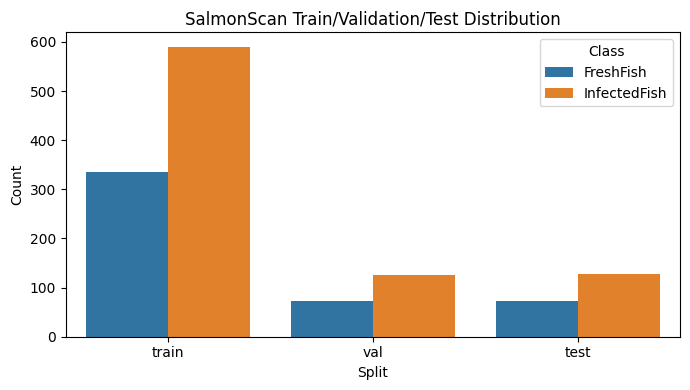

In [6]:
# Cell 6: Plot class distribution

plt.figure(figsize=(7,4))
sns.barplot(data=dist_df, x="Split", y="Count", hue="Class")
plt.title("SalmonScan Train/Validation/Test Distribution")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Data loaders

IMG_SIZE = 224
BATCH_SIZE = 32

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(WORK_DIR / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(WORK_DIR / "val", transform=eval_tfms)
test_ds  = datasets.ImageFolder(WORK_DIR / "test", transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_ds.classes
num_classes = len(class_names)

print(class_names)

['FreshFish', 'InfectedFish']


In [8]:
# Cell 8: Model factory with basic CNN + recent models

def build_model(model_name, num_classes=2):

    # Basic CNN / classical transfer-learning baselines
    if model_name == "alexnet":
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "vgg19":
        model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "inception_v3":
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    # Recent lightweight timm model from Hugging Face
    elif model_name == "hf_mobilenetv3_small_lamb":
        model = timm.create_model(
            "hf_hub:timm/mobilenetv3_small_100.lamb_in1k",
            pretrained=True,
            num_classes=num_classes
        )

    # Vision transformer baselines
    elif model_name == "vit_base":
        model = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_classes
        )

    elif model_name == "swinv2_tiny":
        model = timm.create_model(
            "swinv2_tiny_window8_256",
            pretrained=True,
            num_classes=num_classes
        )

    # Domain-unrelated but requested HF ViT model; useful only as transfer baseline
    elif model_name == "falconsai_nsfw_vit":
        model = AutoModelForImageClassification.from_pretrained(
            "Falconsai/nsfw_image_detection",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(DEVICE)

In [9]:
# Cell 9: Training loop

def forward_logits(model, x):
    out = model(x)
    if hasattr(out, "logits"):
        return out.logits
    if isinstance(out, tuple):
        return out[0]
    return out


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    criterion = nn.CrossEntropyLoss()
    total_loss = 0
    all_y, all_pred, all_prob = [], [], []

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = forward_logits(model, x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * x.size(0)
            all_y.extend(y.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_y, all_pred)
    f1 = f1_score(all_y, all_pred)

    return avg_loss, acc, f1, np.array(all_y), np.array(all_pred), np.array(all_prob)


def train_model(model_name, epochs=10, lr=1e-4):
    model = build_model(model_name, num_classes)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = []
    best_f1 = -1
    best_path = f"/content/best_{model_name}.pt"

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1, *_ = run_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_f1, *_ = run_one_epoch(model, val_loader)

        row = {
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "train_acc": tr_acc,
            "val_acc": va_acc,
            "train_f1": tr_f1,
            "val_f1": va_f1
        }

        history.append(row)
        print(row)

        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, pd.DataFrame(history), best_path

In [11]:
# Cell 10: Select models to run

MODELS_TO_RUN = [
    # Basic CNN baselines
    "alexnet",
    "vgg16",
    "vgg19",
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",

    # Recent/lightweight/requested models
    "hf_mobilenetv3_small_lamb",

    # Transformer models
    "vit_base",

    # Requested HF transfer baseline
    "falconsai_nsfw_vit"
]

all_histories = {}
trained_models = {}

for m in MODELS_TO_RUN:
    print("\n" + "="*80)
    print("Training:", m)
    print("="*80)

    try:
        model, hist, path = train_model(m, epochs=20, lr=1e-4)
        all_histories[m] = hist
        trained_models[m] = model
    except Exception as e:
        print(f"Skipped {m} due to error: {e}")


Training: alexnet
{'epoch': 1, 'train_loss': 0.3279158299516987, 'val_loss': 0.17909688419765896, 'train_acc': 0.8529729729729729, 'val_acc': 0.9090909090909091, 'train_f1': 0.8868552412645591, 'val_f1': 0.9243697478991597}
{'epoch': 2, 'train_loss': 0.1753178609303526, 'val_loss': 0.3290238148636288, 'train_acc': 0.9210810810810811, 'val_acc': 0.8787878787878788, 'train_f1': 0.9388097233864208, 'val_f1': 0.8947368421052632}
{'epoch': 3, 'train_loss': 0.12720399352344305, 'val_loss': 0.12607610045057355, 'train_acc': 0.9437837837837838, 'val_acc': 0.9595959595959596, 'train_f1': 0.9559322033898305, 'val_f1': 0.967479674796748}
{'epoch': 4, 'train_loss': 0.11128307509462576, 'val_loss': 0.07972035474247402, 'train_acc': 0.9535135135135135, 'val_acc': 0.9646464646464646, 'train_f1': 0.9637130801687763, 'val_f1': 0.9727626459143969}
{'epoch': 5, 'train_loss': 0.13772902158466546, 'val_loss': 0.09696721247952393, 'train_acc': 0.932972972972973, 'val_acc': 0.9646464646464646, 'train_f1': 0

100%|██████████| 528M/528M [00:03<00:00, 156MB/s]


{'epoch': 1, 'train_loss': 0.4329232887077976, 'val_loss': 0.1439032747287943, 'train_acc': 0.8151351351351351, 'val_acc': 0.9343434343434344, 'train_f1': 0.8583264291632146, 'val_f1': 0.9482071713147411}
{'epoch': 2, 'train_loss': 0.17225124713536855, 'val_loss': 0.1451329898954642, 'train_acc': 0.9275675675675675, 'val_acc': 0.9191919191919192, 'train_f1': 0.9443059019118869, 'val_f1': 0.9327731092436975}
{'epoch': 3, 'train_loss': 0.14224033295302776, 'val_loss': 0.2798983236454954, 'train_acc': 0.9427027027027027, 'val_acc': 0.8888888888888888, 'train_f1': 0.9548167092924126, 'val_f1': 0.9043478260869565}
{'epoch': 4, 'train_loss': 0.0812610309832805, 'val_loss': 0.07596680597223417, 'train_acc': 0.9632432432432433, 'val_acc': 0.9696969696969697, 'train_f1': 0.9711375212224108, 'val_f1': 0.9758064516129032}
{'epoch': 5, 'train_loss': 0.0738272879125135, 'val_loss': 0.12331081971977696, 'train_acc': 0.9664864864864865, 'val_acc': 0.9494949494949495, 'train_f1': 0.9737065309584394, '

100%|██████████| 548M/548M [00:06<00:00, 87.8MB/s]


{'epoch': 1, 'train_loss': 0.426890367092313, 'val_loss': 0.14171207553208476, 'train_acc': 0.7783783783783784, 'val_acc': 0.9444444444444444, 'train_f1': 0.8304383788254756, 'val_f1': 0.9568627450980393}
{'epoch': 2, 'train_loss': 0.21434251991478173, 'val_loss': 0.08772561766884544, 'train_acc': 0.9102702702702703, 'val_acc': 0.9545454545454546, 'train_f1': 0.9297205757832345, 'val_f1': 0.9641434262948207}
{'epoch': 3, 'train_loss': 0.19995446406506204, 'val_loss': 0.1544170229121892, 'train_acc': 0.9275675675675675, 'val_acc': 0.9292929292929293, 'train_f1': 0.9439330543933054, 'val_f1': 0.9411764705882353}
{'epoch': 4, 'train_loss': 0.10022095908989777, 'val_loss': 0.15940698589941468, 'train_acc': 0.9589189189189189, 'val_acc': 0.9343434343434344, 'train_f1': 0.967741935483871, 'val_f1': 0.9456066945606695}
{'epoch': 5, 'train_loss': 0.08968014194353206, 'val_loss': 0.13827541929603826, 'train_acc': 0.9654054054054054, 'val_acc': 0.9595959595959596, 'train_f1': 0.972972972972973, 

...

{'epoch': 1, 'train_loss': 0.5304966139310116, 'val_loss': 0.1487069512256468, 'train_acc': 0.7924324324324324, 'val_acc': 0.9444444444444444, 'train_f1': 0.8402662229617305, 'val_f1': 0.9561752988047809}
{'epoch': 2, 'train_loss': 0.18473681946058532, 'val_loss': 0.11348008085982968, 'train_acc': 0.9243243243243243, 'val_acc': 0.9444444444444444, 'train_f1': 0.9409780775716695, 'val_f1': 0.9554655870445344}
{'epoch': 3, 'train_loss': 0.15225315849523285, 'val_loss': 0.10299435333170072, 'train_acc': 0.9254054054054054, 'val_acc': 0.9595959595959596, 'train_f1': 0.9416737109044802, 'val_f1': 0.9689922480620154}
{'epoch': 4, 'train_loss': 0.14775458968974448, 'val_loss': 0.07598729235957367, 'train_acc': 0.9437837837837838, 'val_acc': 0.9747474747474747, 'train_f1': 0.9563758389261745, 'val_f1': 0.9800796812749004}
{'epoch': 5, 'train_loss': 0.07265569567680359, 'val_loss': 0.06497768026710761, 'train_acc': 0.9751351351351352, 'val_acc': 0.9696969696969697, 'train_f1': 0.980557903634826

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.46356643742806203, 'val_loss': 0.2134262841157239, 'train_acc': 0.841081081081081, 'val_acc': 0.898989898989899, 'train_f1': 0.8759493670886076, 'val_f1': 0.9137931034482759}
{'epoch': 2, 'train_loss': 0.12435061021431072, 'val_loss': 0.0913560926312148, 'train_acc': 0.9448648648648649, 'val_acc': 0.9747474747474747, 'train_f1': 0.9566694987255735, 'val_f1': 0.9799196787148594}
{'epoch': 3, 'train_loss': 0.12424650023917894, 'val_loss': 0.10933856444075854, 'train_acc': 0.9545945945945946, 'val_acc': 0.9545454545454546, 'train_f1': 0.964041095890411, 'val_f1': 0.9652509652509652}
{'epoch': 4, 'train_loss': 0.0985551684853193, 'val_loss': 0.053164715869258146, 'train_acc': 0.961081081081081, 'val_acc': 0.98989898989899, 'train_f1': 0.9698492462311558, 'val_f1': 0.992}
{'epoch': 5, 'train_loss': 0.04397951244401771, 'val_loss': 0.0594217497102841, 'train_acc': 0.9827027027027027, 'val_acc': 0.9848484848484849, 'train_f1': 0.9863945578231292, 'val_f1': 0.98804

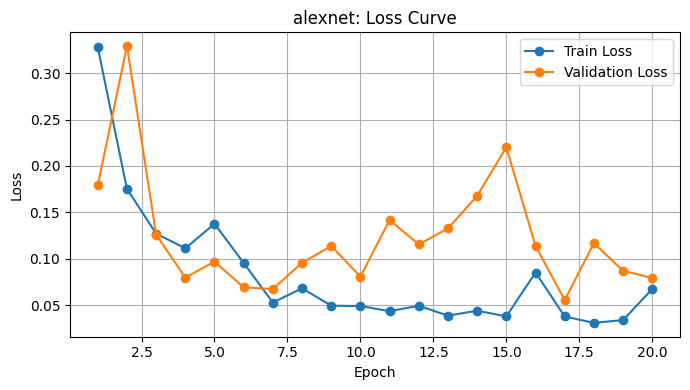

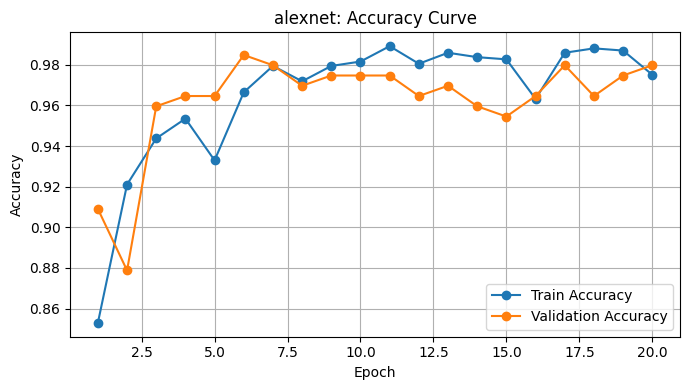

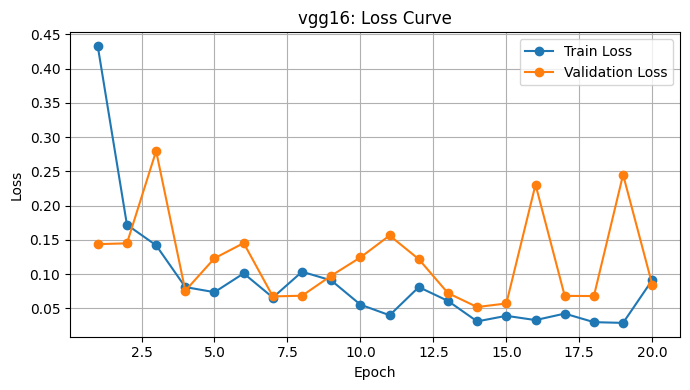

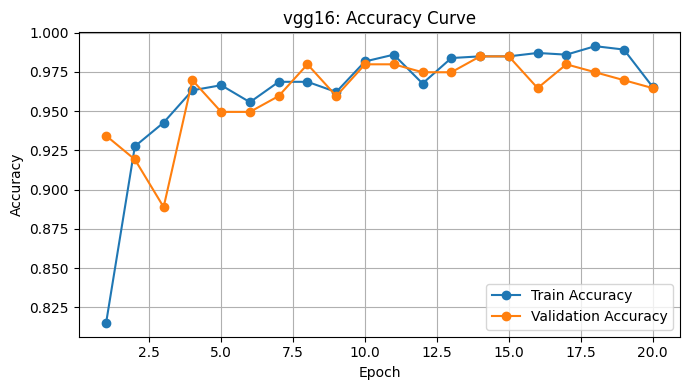

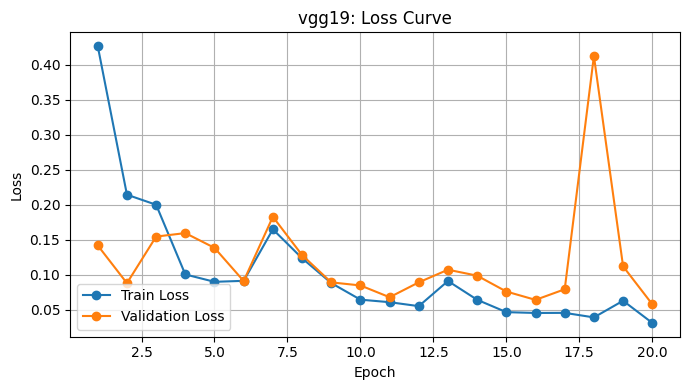

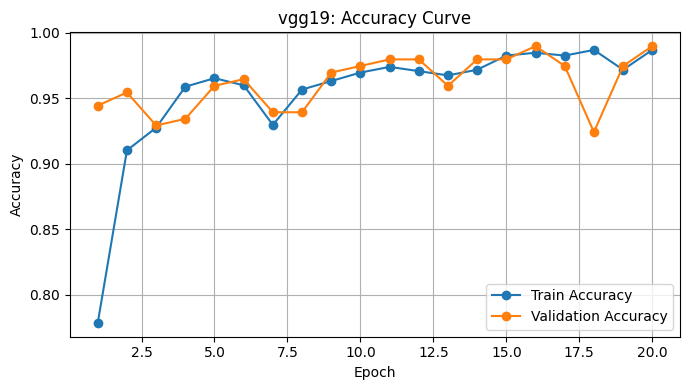

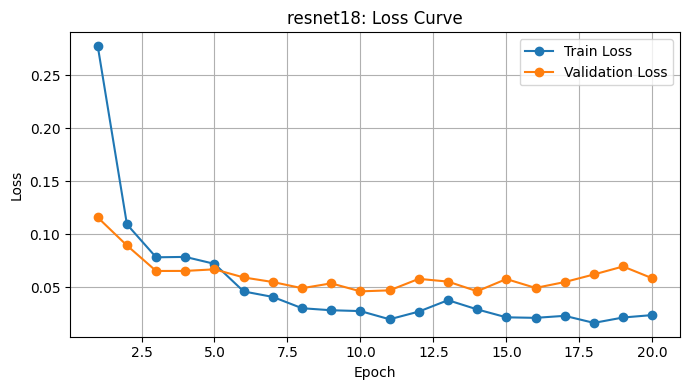

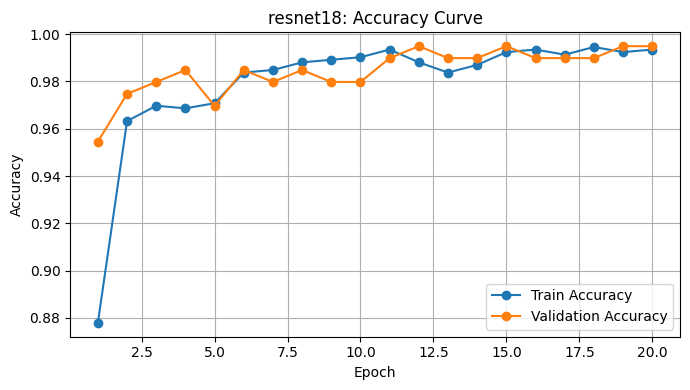

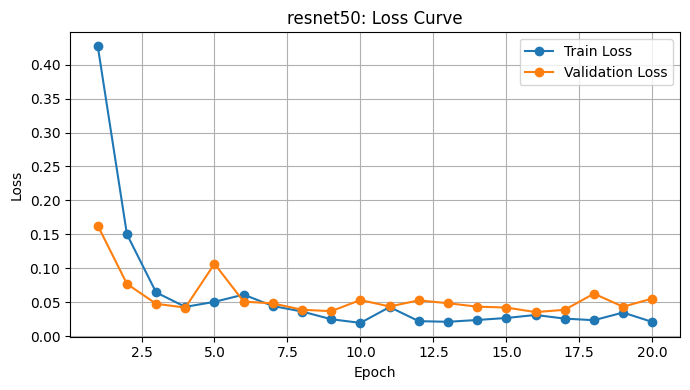

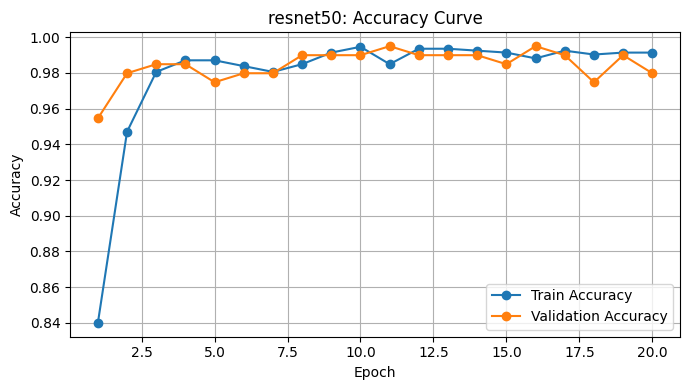

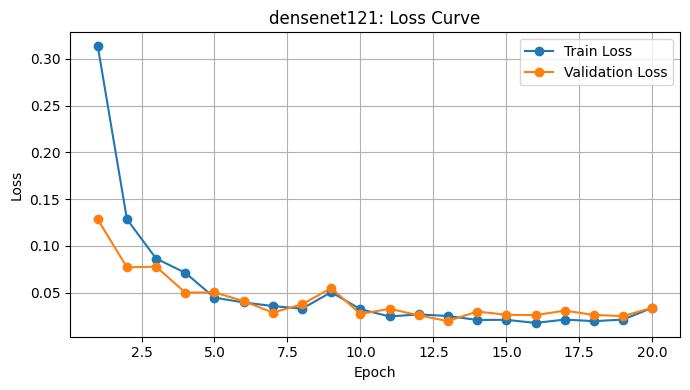

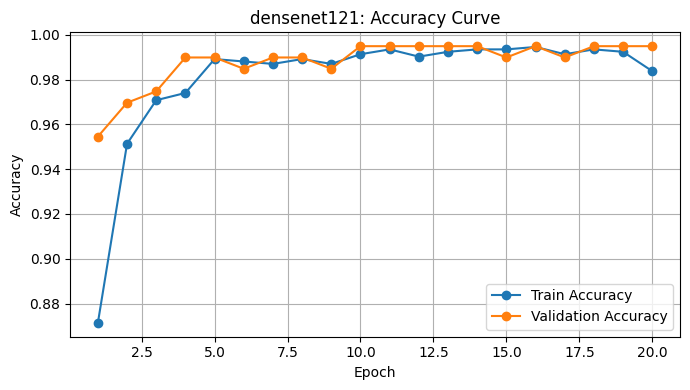

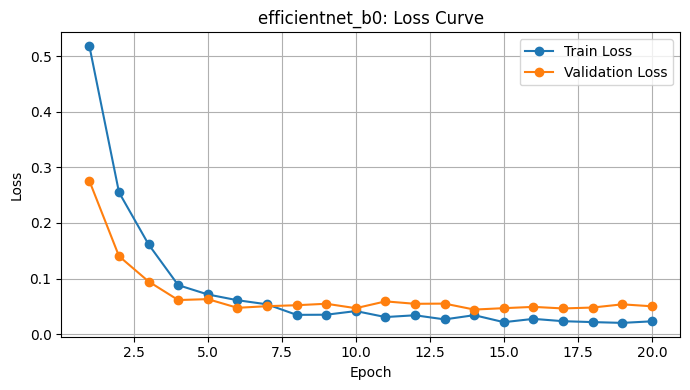

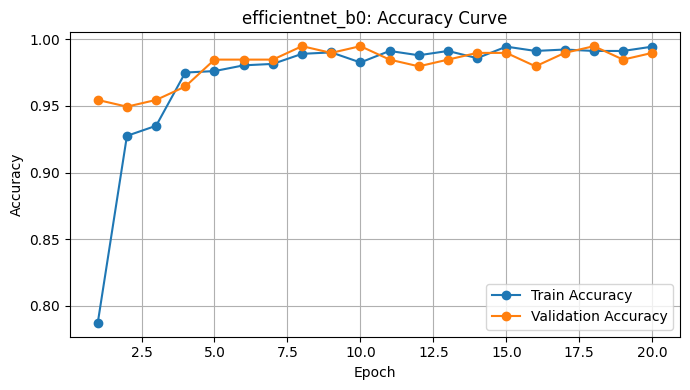

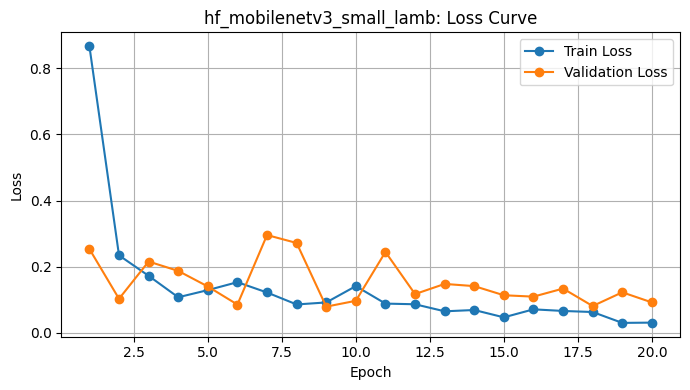

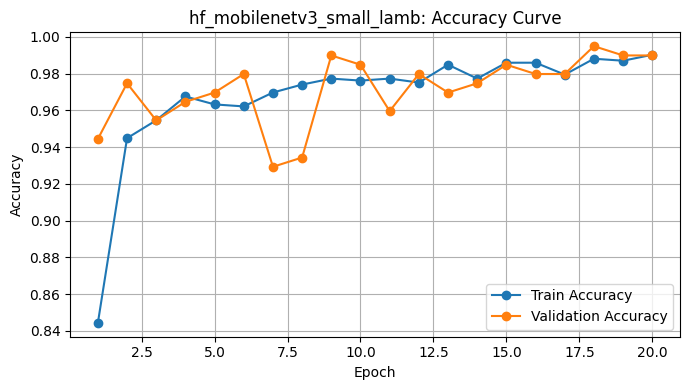

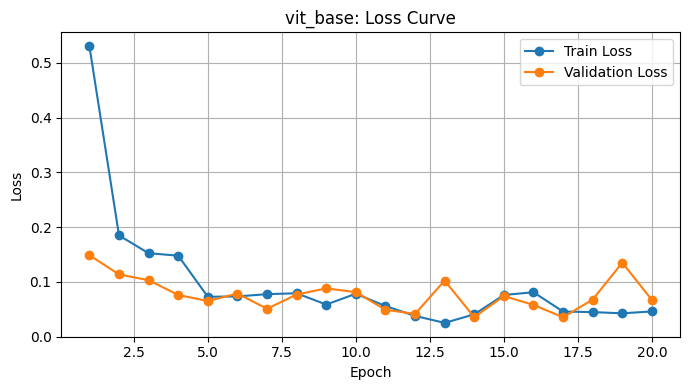

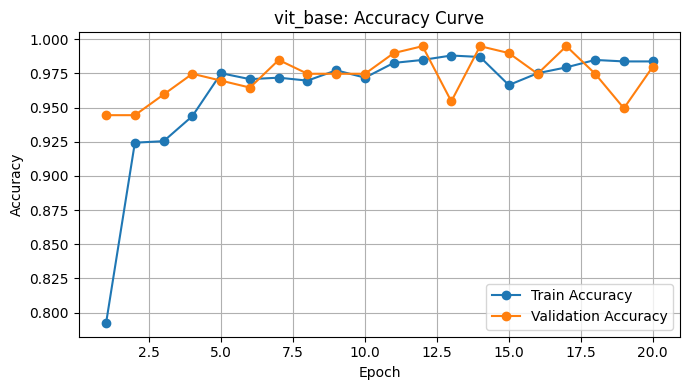

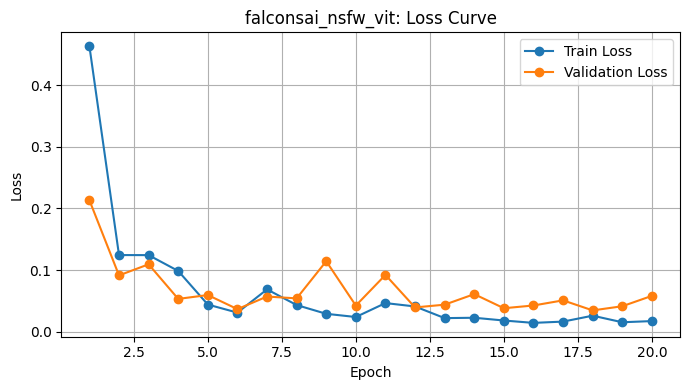

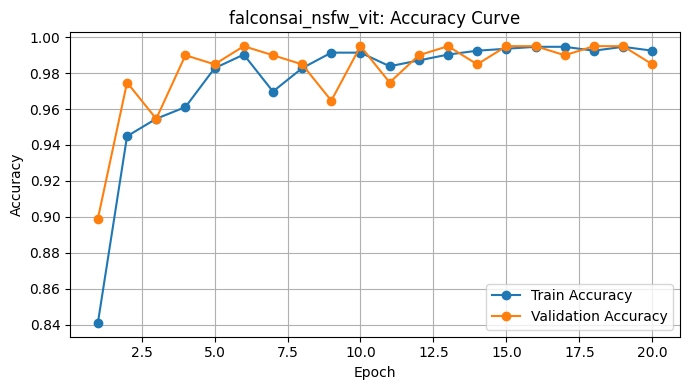

In [12]:
# Cell 11: Plot loss and accuracy

for model_name, hist in all_histories.items():

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train Loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name}: Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(hist["epoch"], hist["val_acc"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
# Cell 12: Test metrics

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall/Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


results = []
pred_store = {}

for model_name, model in trained_models.items():
    test_loss, test_acc, test_f1, y_true, y_pred, y_prob = run_one_epoch(model, test_loader)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["Model"] = model_name
    metrics["Test Loss"] = test_loss

    results.append(metrics)
    pred_store[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

results_df = pd.DataFrame(results)

cols = [
    "Model", "Test Loss", "Accuracy", "Precision", "Recall/Sensitivity",
    "Specificity", "F1-score", "Balanced Accuracy", "MCC",
    "Cohen Kappa", "ROC-AUC", "PR-AUC", "Brier Score",
    "TP", "TN", "FP", "FN"
]

results_df = results_df[cols]
print(results_df.round(4).to_string(index=False))
results_df.to_csv("/content/salmon_model_test_metrics.csv", index=False)

                    Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
                  alexnet     0.1067    0.9497     0.9535              0.9685       0.9167    0.9609             0.9426 0.8907       0.8905   0.9934  0.9963       0.0341 123  66   6   4
                    vgg16     0.1363    0.9849     0.9921              0.9843       0.9861    0.9881             0.9852 0.9675       0.9675   0.9937  0.9965       0.0179 125  71   1   2
                    vgg19     0.1721    0.9799     0.9843              0.9843       0.9722    0.9843             0.9782 0.9565       0.9565   0.9908  0.9905       0.0184 125  70   2   2
                 resnet18     0.0928    0.9899     1.0000              0.9843       1.0000    0.9921             0.9921 0.9786       0.9784   0.9973  0.9986       0.0133 125  72   0   2
                 resnet50     0.0947    0.9698     0.9764             

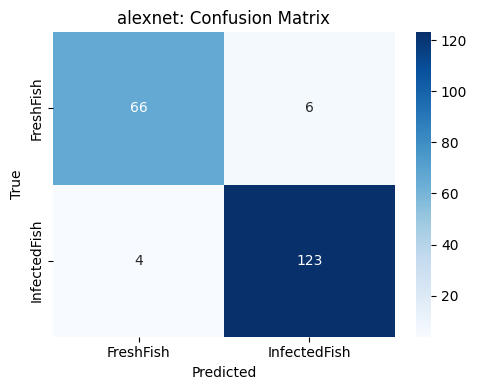

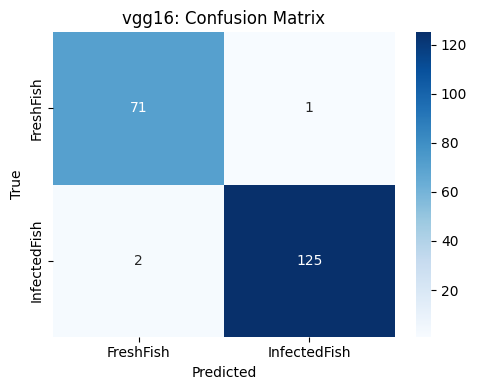

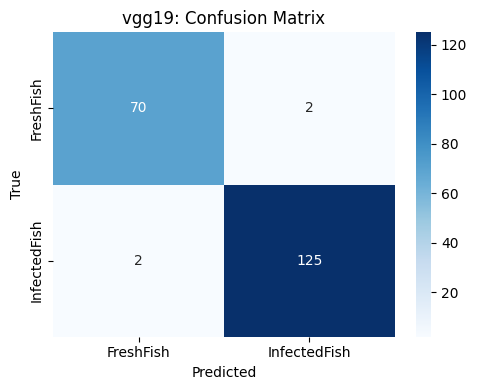

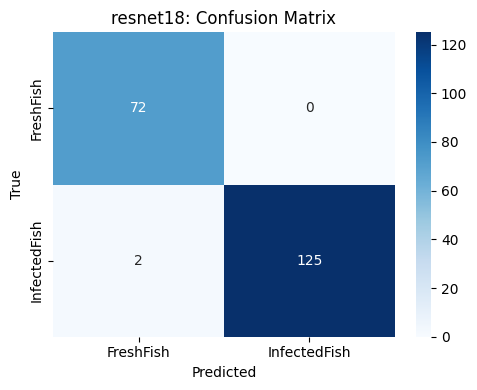

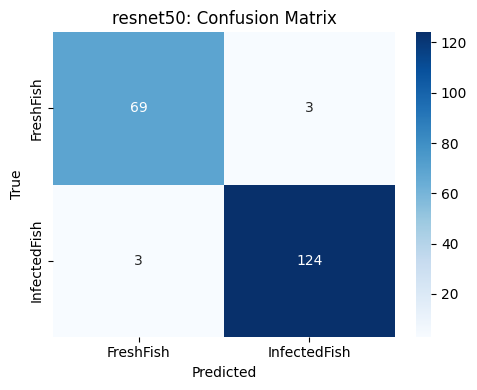

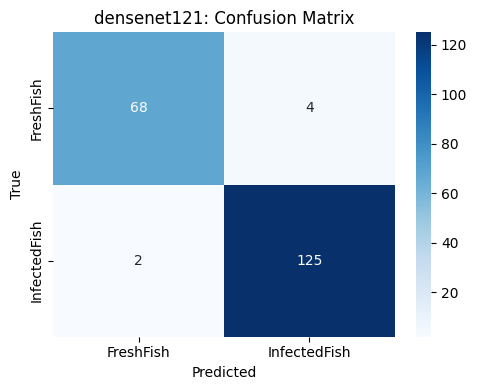

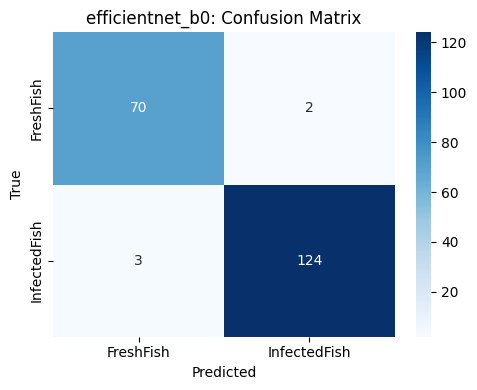

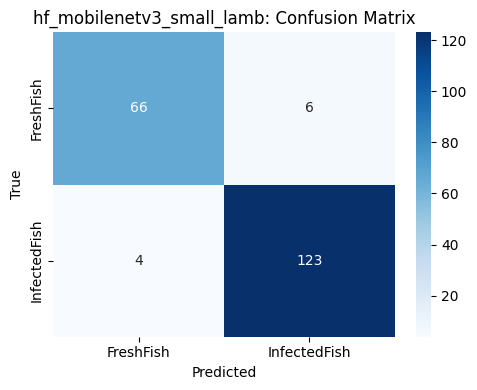

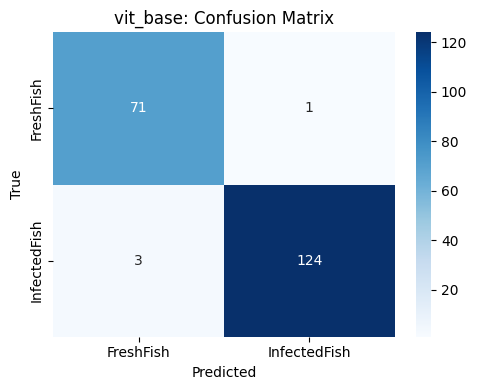

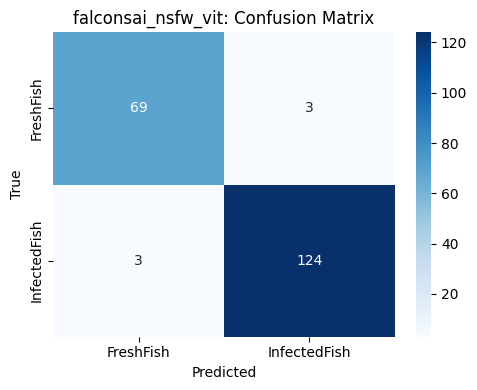

In [14]:
# Cell 13: Confusion matrices

for model_name, item in pred_store.items():
    cm = confusion_matrix(item["y_true"], item["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

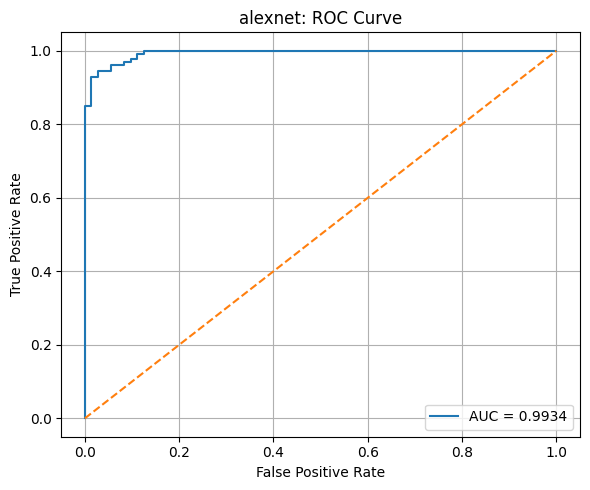

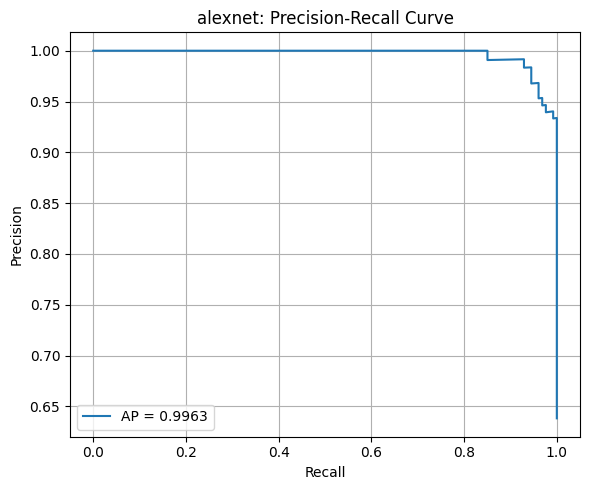

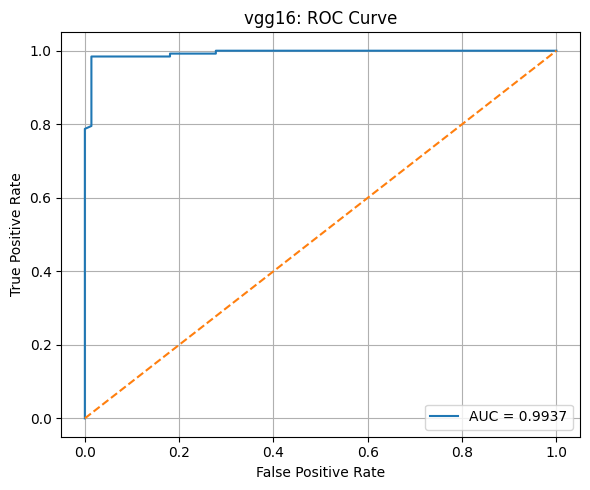

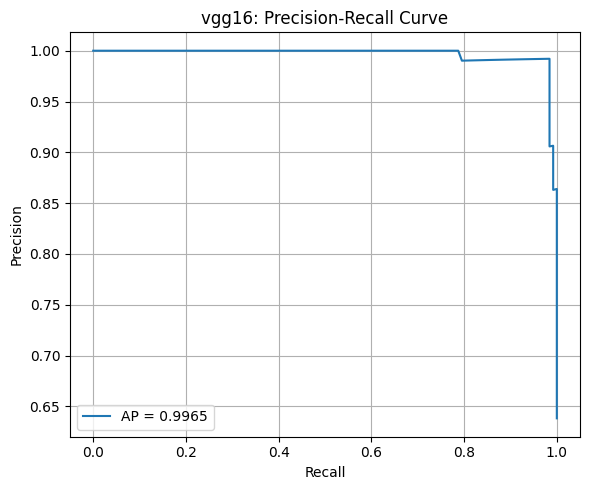

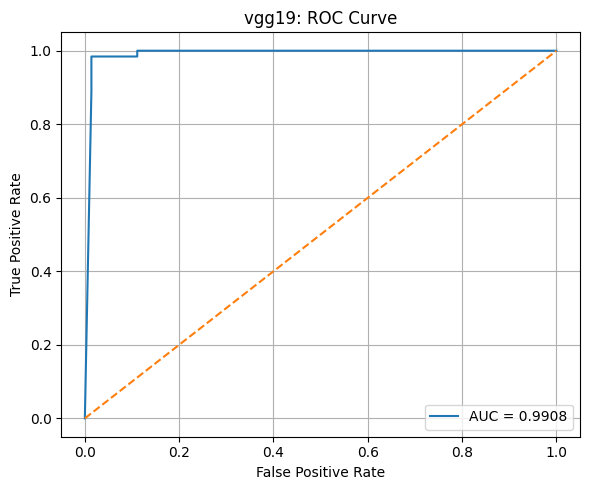

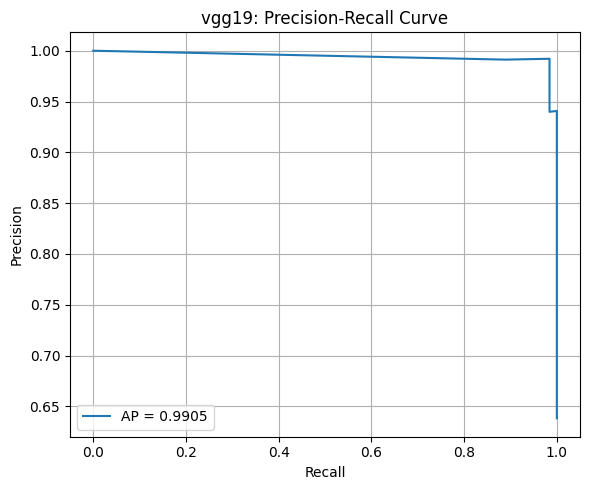

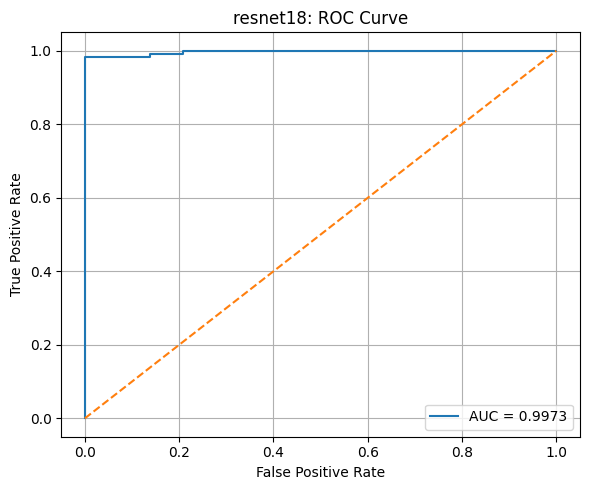

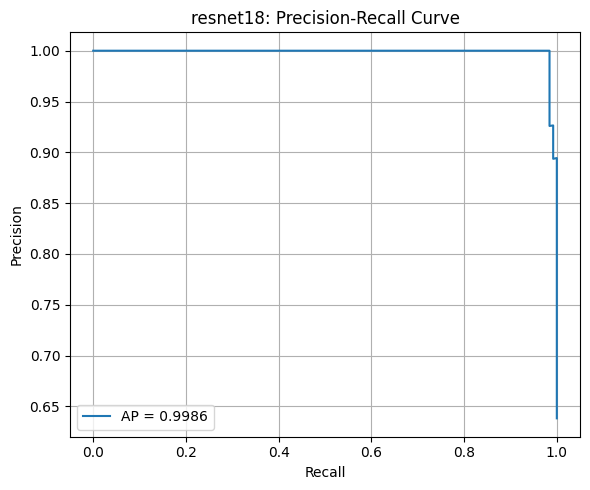

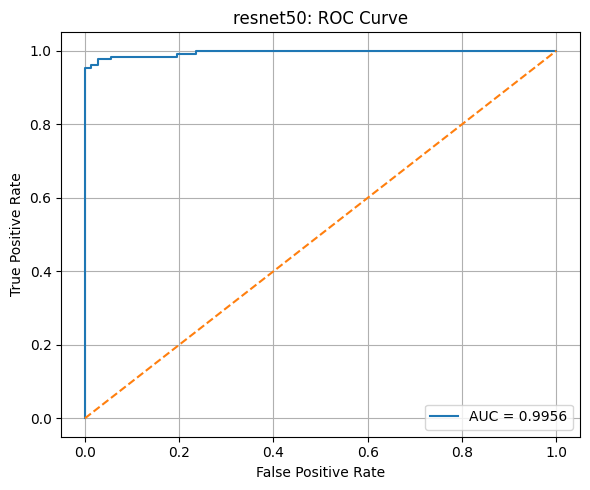

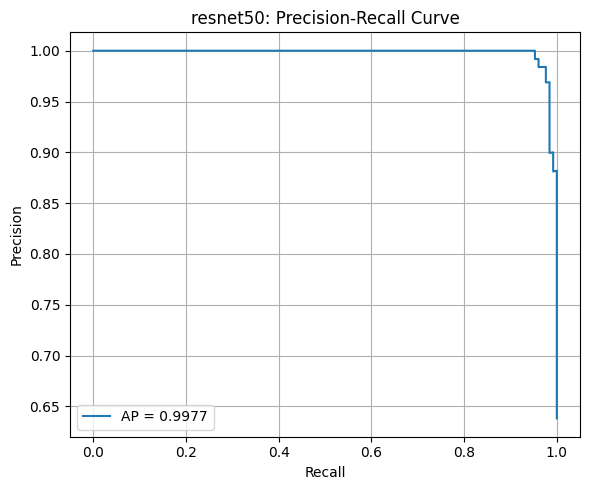

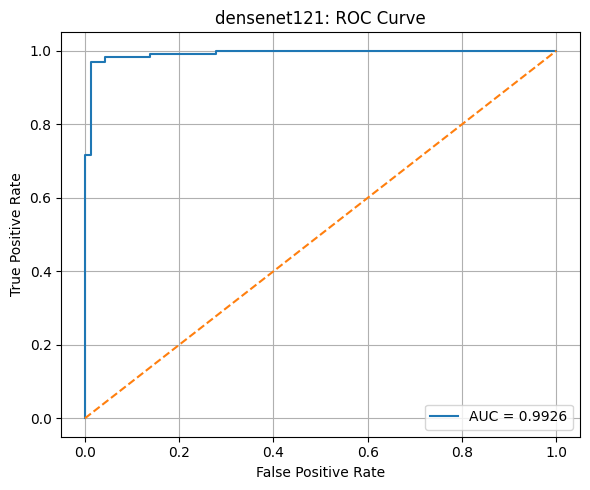

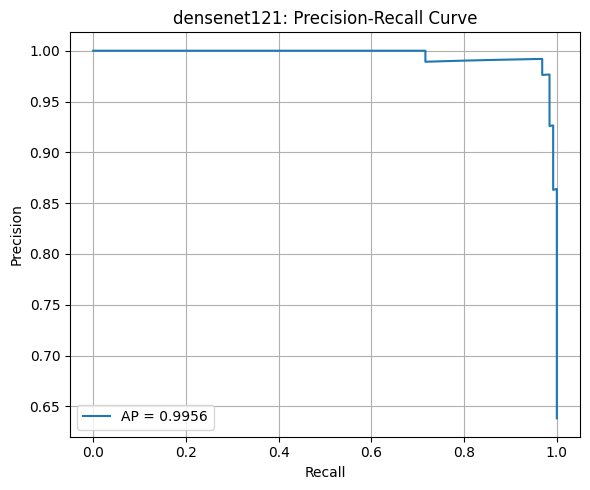

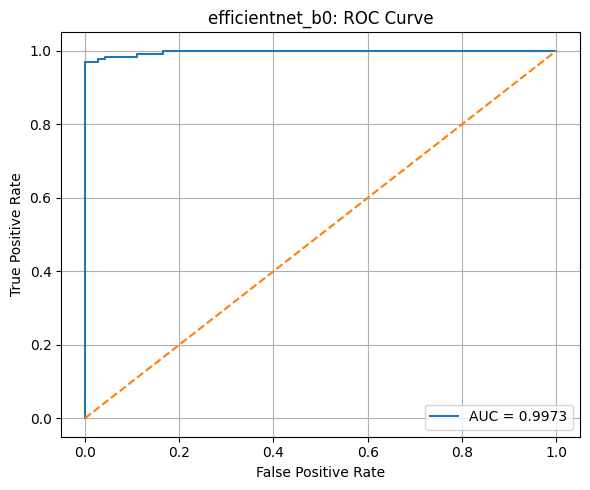

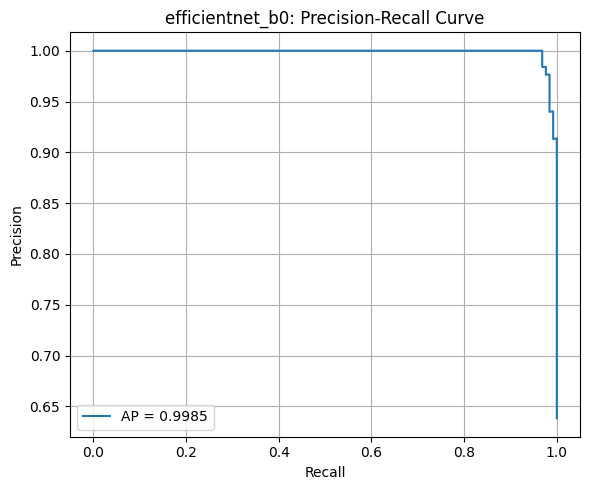

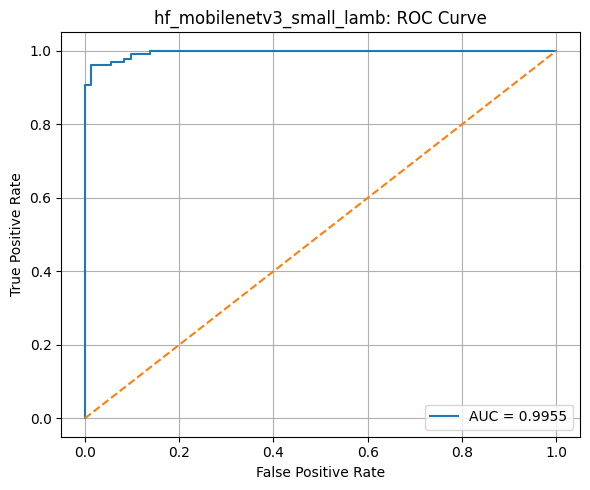

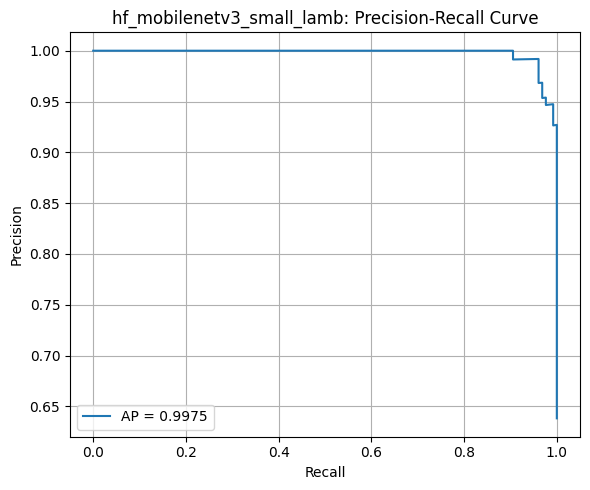

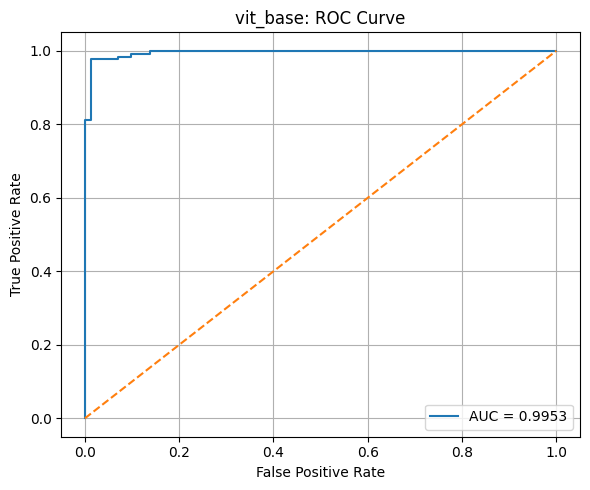

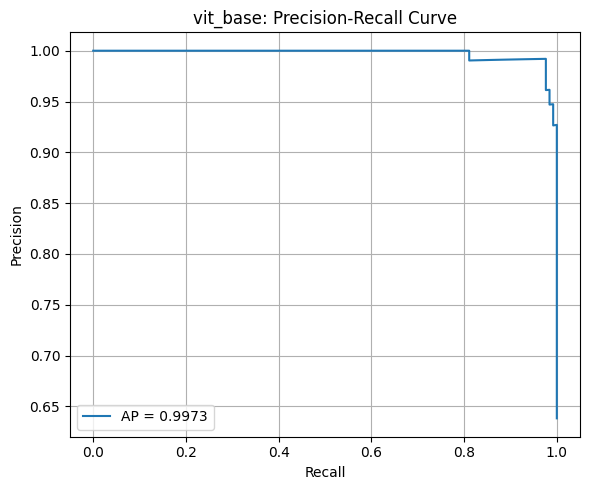

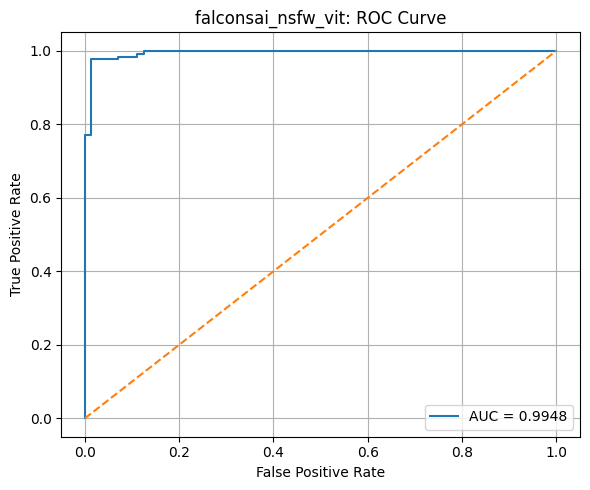

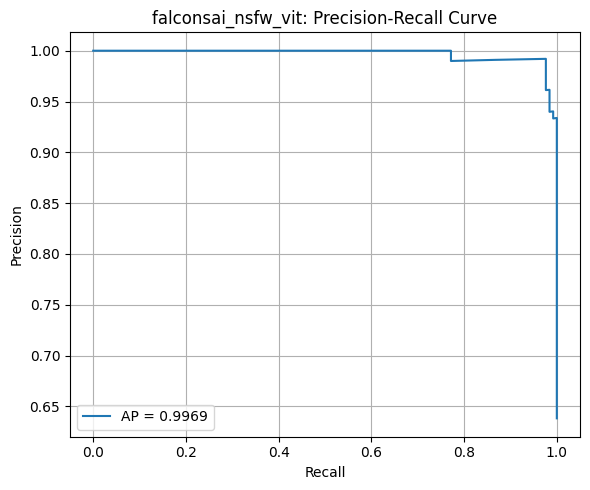

In [15]:
# Cell 14: ROC and PR curves

from sklearn.metrics import roc_curve, precision_recall_curve, auc

for model_name, item in pred_store.items():
    y_true = item["y_true"]
    y_prob = item["y_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{model_name}: ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP = {average_precision_score(y_true, y_prob):.4f}")
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [16]:
# Cell 15: Copy-paste classification reports

for model_name, item in pred_store.items():
    print("\n" + "="*100)
    print(model_name)
    print("="*100)
    print(classification_report(
        item["y_true"],
        item["y_pred"],
        target_names=class_names,
        digits=4
    ))


alexnet
              precision    recall  f1-score   support

   FreshFish     0.9429    0.9167    0.9296        72
InfectedFish     0.9535    0.9685    0.9609       127

    accuracy                         0.9497       199
   macro avg     0.9482    0.9426    0.9453       199
weighted avg     0.9496    0.9497    0.9496       199


vgg16
              precision    recall  f1-score   support

   FreshFish     0.9726    0.9861    0.9793        72
InfectedFish     0.9921    0.9843    0.9881       127

    accuracy                         0.9849       199
   macro avg     0.9823    0.9852    0.9837       199
weighted avg     0.9850    0.9849    0.9849       199


vgg19
              precision    recall  f1-score   support

   FreshFish     0.9722    0.9722    0.9722        72
InfectedFish     0.9843    0.9843    0.9843       127

    accuracy                         0.9799       199
   macro avg     0.9782    0.9782    0.9782       199
weighted avg     0.9799    0.9799    0.9799       1

In [17]:
# Cell 16: Hybrid ensemble

top_models = results_df.sort_values("F1-score", ascending=False)["Model"].head(3).tolist()
print("Top models used for hybrid ensemble:", top_models)

y_true = pred_store[top_models[0]]["y_true"]
avg_prob = np.mean([pred_store[m]["y_prob"] for m in top_models], axis=0)
avg_pred = (avg_prob >= 0.5).astype(int)

ensemble_metrics = compute_metrics(y_true, avg_pred, avg_prob)
ensemble_metrics["Model"] = "Hybrid_Probability_Ensemble_Top3"
ensemble_metrics["Test Loss"] = np.nan

ensemble_df = pd.DataFrame([ensemble_metrics])[cols]
print(ensemble_df.round(4).to_string(index=False))

Top models used for hybrid ensemble: ['resnet18', 'vgg16', 'vgg19']
                           Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
Hybrid_Probability_Ensemble_Top3        NaN    0.9849     0.9921              0.9843       0.9861    0.9881             0.9852 0.9675       0.9675   0.9984  0.9991       0.0141 125  71   1   2


In [18]:
# Cell 17: McNemar statistical test


best_two = results_df.sort_values("F1-score", ascending=False)["Model"].head(2).tolist()

m1, m2 = best_two

y_true = pred_store[m1]["y_true"]
p1 = pred_store[m1]["y_pred"]
p2 = pred_store[m2]["y_pred"]

correct1 = p1 == y_true
correct2 = p2 == y_true

table = [
    [np.sum(correct1 & correct2), np.sum(correct1 & ~correct2)],
    [np.sum(~correct1 & correct2), np.sum(~correct1 & ~correct2)]
]

result = mcnemar(table, exact=True)

print("Compared models:", m1, "vs", m2)
print("McNemar contingency table:", table)
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

Compared models: resnet18 vs vgg16
McNemar contingency table: [[np.int64(196), np.int64(1)], [np.int64(0), np.int64(2)]]
Statistic: 0.0
p-value: 1.0


In [19]:
# Cell 18: Inference speed benchmark

def benchmark_model(model, loader):
    model.eval()
    n = 0

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            _ = forward_logits(model, x)
            n += x.size(0)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return {
        "Images": n,
        "Total Time (s)": elapsed,
        "Images/sec": n / elapsed,
        "ms/image": (elapsed / n) * 1000
    }


benchmarks = []

for model_name, model in trained_models.items():
    b = benchmark_model(model, test_loader)
    b["Model"] = model_name
    benchmarks.append(b)

bench_df = pd.DataFrame(benchmarks)
print(bench_df.round(4).to_string(index=False))
bench_df.to_csv("/content/salmon_inference_benchmark.csv", index=False)

 Images  Total Time (s)  Images/sec  ms/image                     Model
    199          1.3410    148.3916    6.7389                   alexnet
    199          1.5637    127.2591    7.8580                     vgg16
    199          2.5361     78.4661   12.7444                     vgg19
    199          1.6157    123.1690    8.1189                  resnet18
    199          1.4342    138.7538    7.2070                  resnet50
    199          1.4848    134.0211    7.4615               densenet121
    199          1.3799    144.2082    6.9344           efficientnet_b0
    199          1.3884    143.3284    6.9770 hf_mobilenetv3_small_lamb
    199          2.7489     72.3919   13.8137                  vit_base
    199          2.7517     72.3188   13.8277        falconsai_nsfw_vit


In [20]:
# Cell 19: YOLO26 classifier

from ultralytics import YOLO

yolo_model = YOLO("yolo26n-cls.pt")

yolo_results = yolo_model.train(
    data=str(WORK_DIR),
    epochs=30,
    imgsz=224,
    batch=32,
    device=0 if torch.cuda.is_available() else "cpu",
    project="/content/yolo26_salmon",
    name="yolo26n_cls_salmon",
    seed=SEED
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/salmon_ready, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, i

In [21]:
# Cell 20: YOLO26 validation

best_yolo_path = "/content/yolo26_salmon/yolo26n_cls_salmon/weights/best.pt"

best_yolo = YOLO(best_yolo_path)

yolo_metrics = best_yolo.val(
    data=str(WORK_DIR),
    split="test",
    imgsz=224,
    device=0 if torch.cuda.is_available() else "cpu"
)

print("YOLO26 Top-1 Accuracy:", yolo_metrics.top1)
print("YOLO26 Top-5 Accuracy:", yolo_metrics.top5)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/salmon_ready/train... found 925 images in 2 classes ✅ 
val: /content/salmon_ready/val... found 198 images in 2 classes ✅ 
test: /content/salmon_ready/test... found 199 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1884.9±465.0 MB/s, size: 262.6 KB)
test: Scanning /content/salmon_ready/test... 199 images, 0 corrupt: 100% ━━━━━━━━━━━━ 199/199 1.2Kit/s 0.2s
test: New cache created: /content/salmon_ready/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 6.9it/s 1.9s
                   all       0.96          1
Speed: 0.5ms preprocess, 2.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
YOLO26 Top-1 Accuracy: 0.9597989916801453
YOLO26 Top-5 Accuracy: 1.0


In [22]:
# Cell 21: Export all publication tables

final_results_df = pd.concat([results_df, ensemble_df], ignore_index=True)

with pd.ExcelWriter("/content/salmon_publication_results_full.xlsx") as writer:
    dist_df.to_excel(writer, sheet_name="Dataset_Distribution", index=False)
    final_results_df.to_excel(writer, sheet_name="Model_Test_Metrics", index=False)
    bench_df.to_excel(writer, sheet_name="Inference_Benchmark", index=False)

print("Saved: /content/salmon_publication_results_full.xlsx")
print(final_results_df.round(4).to_string(index=False))

Saved: /content/salmon_publication_results_full.xlsx
                           Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
                         alexnet     0.1067    0.9497     0.9535              0.9685       0.9167    0.9609             0.9426 0.8907       0.8905   0.9934  0.9963       0.0341 123  66   6   4
                           vgg16     0.1363    0.9849     0.9921              0.9843       0.9861    0.9881             0.9852 0.9675       0.9675   0.9937  0.9965       0.0179 125  71   1   2
                           vgg19     0.1721    0.9799     0.9843              0.9843       0.9722    0.9843             0.9782 0.9565       0.9565   0.9908  0.9905       0.0184 125  70   2   2
                        resnet18     0.0928    0.9899     1.0000              0.9843       1.0000    0.9921             0.9921 0.9786       0.9784   0.9973  0.9986       0.013